# Stacked Area Chart

This section showcases the stacked area chart. It contains examples of how to create stacked area charts using the [datachart.charts.StackedAreaChart](../../../references/charts/#datachart.charts.StackedAreaChart) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-stacked-area-chart), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the stacked area charts are created using the `StackedAreaChart` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import StackedAreaChart

## Stacked Area Chart Input Attributes

The `StackedAreaChart` function accepts keyword arguments for chart configuration. The main argument is `data`, which contains the series to stack. For a single band, `data` is a list of data points; for a stack of several series, `data` is a list of such lists — every series must hold the same `x` values in the same order, as the bands sit on top of one another point by point.

```python
StackedAreaChart(
    data=[                                              # The series to stack, first at the bottom (or one list of points for a single band)
        [
            {
                "x": Union[int, float],                 # The x-axis value
                "y": Union[int, float],                 # The y-axis value
            },
            ...
        ],
        ...
    ],
    baseline=Optional[str],                             # Where the first series starts: "zero" (default), "percent", "sym", "wiggle", or "weighted_wiggle"
    style={                                             # The style of the bands (optional; a list for multiple series)
        "plot_area_color":          Optional[str],      # The fill color of the band
        "plot_area_hatch":          Optional[str],      # The hatch pattern of the band
        "plot_area_zorder":         Optional[int],      # The zorder of the band
        "plot_stackedarea_alpha":   Optional[float],    # The alpha of the band (0.8 by default)
        "plot_stackedarea_outline": Optional[bool],     # Whether to draw the top edge of the band as a line (False by default)
        "plot_stackedarea_edge_color": Optional[str],    # The stroke color between the bands
        "plot_stackedarea_edge_width": Optional[float],  # The stroke width between the bands (0.6 by default)
        "plot_line_color":          Optional[str],      # The outline color
        "plot_line_width":          Optional[float],    # The outline width
        "plot_line_style":          Optional[str],      # The outline style
    },
    subtitle=Optional[str],                             # The series name, used in the legend (or list for multiple series)
    emphasis=Optional[str],                             # "highlight" or "background" (or list for multiple series)
    emphasis_rule=Optional[dict],                       # One-key rule on a per-series summary; optional "by": mean, median, min, max, sum
    title=Optional[str],                                # The chart title
    xlabel=Optional[str],                               # The x-axis label
    ylabel=Optional[str],                               # The y-axis label
    figsize=Optional[Tuple[float, float]],              # The figure size
    show_legend=Optional[bool],                         # Whether to show the legend
    show_grid=Optional[str],                            # Which grid lines to show
    subplots=Optional[bool],                            # Whether to draw each series unstacked in its own subplot
    max_cols=Optional[int],                             # The maximum number of subplot columns
    sharex=Optional[bool],                              # Whether the subplots share the x-axis
    sharey=Optional[bool],                              # Whether the subplots share the y-axis
    xmin=Optional[float],                               # The minimum x-axis value
    xmax=Optional[float],                               # The maximum x-axis value
    ymin=Optional[float],                               # The minimum y-axis value
    ymax=Optional[float],                               # The maximum y-axis value
    scalex=Optional[str],                               # The x-axis scale
    scaley=Optional[str],                               # The y-axis scale
    vlines=Optional[Union[dict, List[dict]]],           # The vertical reference lines
    hlines=Optional[Union[dict, List[dict]]],           # The horizontal reference lines
    vspans=Optional[Union[dict, List[dict]]],           # The vertical reference bands
    hspans=Optional[Union[dict, List[dict]]],           # The horizontal reference bands
    texts=Optional[Union[dict, List[dict]]],            # The text annotations
    x=Optional[str],                                    # The key holding the x-axis value (default: "x")
    y=Optional[str],                                    # The key holding the y-axis value (default: "y")
)
```

For more details, see the [datachart.charts.StackedAreaChart](../../../references/charts/#datachart.charts.StackedAreaChart) function.

## Basics

The examples in this guide share one dataset: the world's electricity generation by source, in terawatt-hours per year from 2000 to 2023 — coal, gas, nuclear, hydro, wind, solar, and everything else (oil, bioenergy, geothermal). The values are rounded from the annual figures published by Ember's *Global Electricity Review* and the Energy Institute's *Statistical Review of World Energy*, and live in the hidden cell below. Generation is a textbook part-to-whole-over-time story: the total more than doubled while the mix underneath it shifted, and a stacked area chart shows both at once.

In [2]:
YEARS = list(range(2000, 2024))

# world electricity generation by source (TWh), rounded from Ember / Energy Institute
GENERATION = {
    "Coal": [5993, 6070, 6350, 6800, 7100, 7322, 7700, 8200, 8300, 8200, 8673, 9200,
             9300, 9600, 9700, 9538, 9500, 9800, 10100, 9900, 9421, 10200, 10300, 10434],
    "Gas": [2753, 2880, 3000, 3100, 3320, 3681, 3830, 4100, 4260, 4230, 4831, 4900,
            5080, 5050, 5150, 5543, 5800, 5900, 6100, 6300, 6268, 6500, 6600, 6634],
    "Nuclear": [2591, 2637, 2660, 2635, 2740, 2768, 2790, 2720, 2730, 2690, 2756, 2580,
                2460, 2480, 2530, 2571, 2610, 2640, 2700, 2790, 2674, 2800, 2680, 2686],
    "Hydro": [2696, 2620, 2700, 2730, 2880, 2982, 3110, 3150, 3290, 3330, 3532, 3560,
              3740, 3830, 3920, 3890, 4050, 4100, 4200, 4270, 4355, 4300, 4340, 4210],
    "Wind": [31, 38, 52, 63, 85, 104, 133, 171, 220, 276, 342, 437,
             524, 640, 716, 833, 960, 1130, 1270, 1420, 1591, 1850, 2100, 2304],
    "Solar": [1, 1, 2, 2, 3, 4, 6, 8, 12, 20, 32, 63,
              97, 136, 197, 250, 329, 443, 570, 690, 846, 1030, 1300, 1629],
    "Other": [1450, 1470, 1480, 1500, 1520, 1530, 1540, 1560, 1560, 1540, 1580, 1600,
              1620, 1640, 1650, 1660, 1680, 1700, 1720, 1730, 1700, 1720, 1740, 1760],
}

SOURCES = list(GENERATION)
generation = [
    [{"x": year, "y": twh} for year, twh in zip(YEARS, GENERATION[source])]
    for source in SOURCES
]

The data is a list of series, one per source, in the order they stack — the first series sits at the bottom. Every series is a list of `{x, y}` points with the year as `x` and the generation as `y`, and all of them share the same years:

In [3]:
{source: points[:3] for source, points in zip(SOURCES, generation)}

{'Coal': [{'x': 2000, 'y': 5993},
  {'x': 2001, 'y': 6070},
  {'x': 2002, 'y': 6350}],
 'Gas': [{'x': 2000, 'y': 2753},
  {'x': 2001, 'y': 2880},
  {'x': 2002, 'y': 3000}],
 'Nuclear': [{'x': 2000, 'y': 2591},
  {'x': 2001, 'y': 2637},
  {'x': 2002, 'y': 2660}],
 'Hydro': [{'x': 2000, 'y': 2696},
  {'x': 2001, 'y': 2620},
  {'x': 2002, 'y': 2700}],
 'Wind': [{'x': 2000, 'y': 31}, {'x': 2001, 'y': 38}, {'x': 2002, 'y': 52}],
 'Solar': [{'x': 2000, 'y': 1}, {'x': 2001, 'y': 1}, {'x': 2002, 'y': 2}],
 'Other': [{'x': 2000, 'y': 1450},
  {'x': 2001, 'y': 1470},
  {'x': 2002, 'y': 1480}]}

**Basic example.** Only the `data` argument is required to draw the stacked area chart. Each source fills the band between the sources below it and its own share, so the top edge of the stack traces the world's total generation, and the y-axis starts at zero where the stack does.

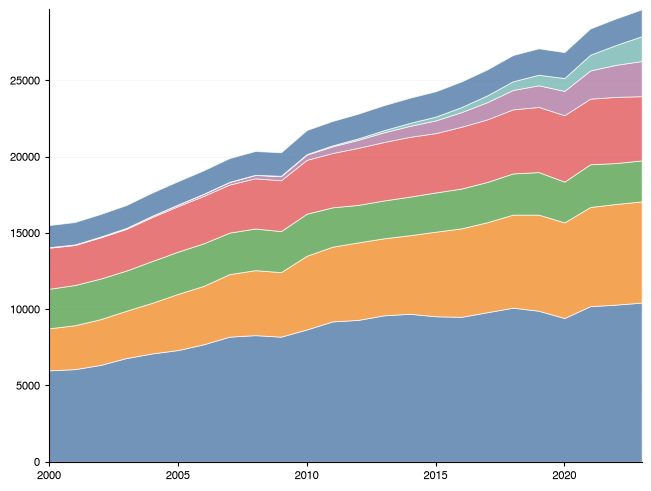

In [4]:
StackedAreaChart(
    # add the data to the chart
    data=generation
).show()

## Customizing the Stacked Area Chart

Every customization is either a keyword argument of `StackedAreaChart` or a `plot_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title and axis labels                 | `title`, `xlabel`, `ylabel`                                             | [Title and axis labels](#title-and-axis-labels) |
| name the series in a legend                 | `subtitle`, `show_legend`                                               | [Legend](#legend) |
| resize the figure                           | `figsize`                                                               | [Figure size and grid](#figure-size-and-grid) |
| show the grid lines                         | `show_grid`                                                             | [Figure size and grid](#figure-size-and-grid) |
| show shares instead of totals               | `baseline="percent"`                                                    | [Baseline](#baseline) |
| centre the stack or draw a streamgraph      | `baseline="sym"`, `"wiggle"`, `"weighted_wiggle"`                       | [Baseline](#baseline) |
| change the band colors, alpha, or hatch     | `style={"plot_area_color": ..., "plot_stackedarea_alpha": ...}`         | [Band style](#band-style) |
| outline the top of every band               | `style={"plot_stackedarea_outline": True}`                              | [Band style](#band-style) |
| print the values on the bands               | `show_values`, `value_format`, `value_step`                            | [Value labels](#value-labels) |
| highlight one series, mute the rest         | `emphasis`                                                              | [Emphasis](#emphasis) |
| highlight the series that match a rule      | `emphasis_rule`                                                         | [Emphasis](#emphasis) |
| mark a year or a level                      | `vlines`, `hlines`                                                      | [Reference lines](#reference-lines) |
| shade a period or a level range             | `hspans`, `vspans`                                                      | [Reference bands](#reference-bands) |
| annotate a point of the chart               | `texts`                                                                 | [Text annotations](#text-annotations) |
| draw every series on its own               | `subplots`                                                              | [Subplots](#subplots) |
| overlay the total or arrange several stacks | `Panel`, `Grid`                                                         | [Composing stacked areas](#composing-stacked-areas) |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `baseline` | [`STACKED_AREA_BASELINE`](../../../references/constants/#datachart.constants.STACKED_AREA_BASELINE) |
| `emphasis` | [`EMPHASIS`](../../../references/constants/#datachart.constants.EMPHASIS) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `value_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `aspect_ratio` | [`ASPECT_RATIO`](../../../references/constants/#datachart.constants.ASPECT_RATIO) |
| `scalex` | [`SCALE`](../../../references/constants/#datachart.constants.SCALE) |
| `scaley` | [`SCALE`](../../../references/constants/#datachart.constants.SCALE) |
| `xticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |
| `yticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |

### Title and axis labels

To add the chart title and axis labels, add the `title`, `xlabel` and `ylabel` attributes.

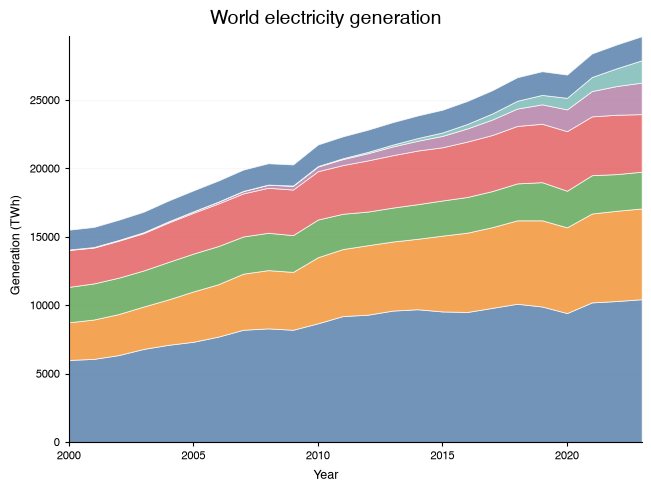

In [5]:
StackedAreaChart(
    data=generation,
    # add the title
    title="World electricity generation",
    # add the x and y axis labels
    xlabel="Year",
    ylabel="Generation (TWh)",
).show()

### Legend

To name the series, add the `subtitle` attribute with one name per series; the `show_legend` attribute then lists them. The legend follows the input order — the first series, at the bottom of the stack, comes first.

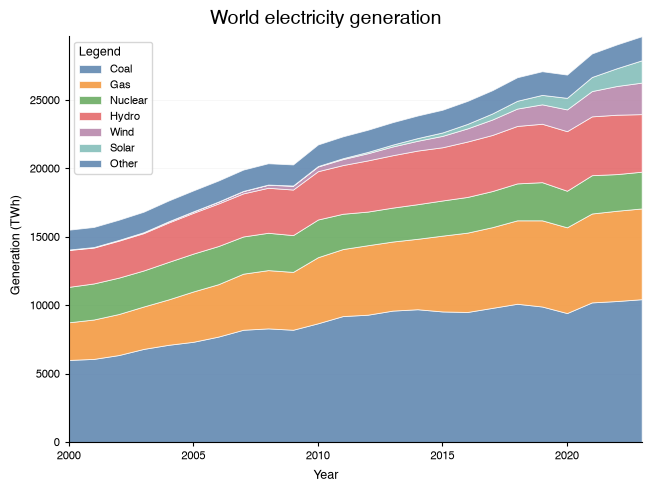

In [6]:
StackedAreaChart(
    data=generation,
    # name the series; the legend lists them bottom to top
    subtitle=SOURCES,
    show_legend=True,
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
).show()

### Figure size and grid

To change the figure size, add the `figsize` attribute. The `figsize` attribute can be a tuple (width, height), values are in inches. The `datachart` package provides a [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE) constant, which contains predefined figure sizes. To change which grid lines show, add the `show_grid` attribute, which supports the values of the [datachart.constants.SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) constant.

In [7]:
from datachart.constants import FIG_SIZE, SHOW_GRID

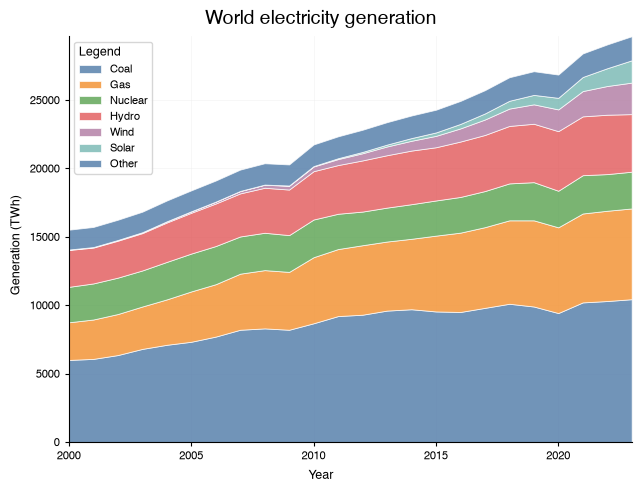

In [8]:
StackedAreaChart(
    data=generation,
    subtitle=SOURCES,
    show_legend=True,
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
    # add to determine the figure size
    figsize=FIG_SIZE.FULL_MEDIUM,
    # add to show the grid lines on both axes
    show_grid=SHOW_GRID.BOTH,
).show()

### Baseline

The `baseline` attribute picks where the first series starts, and so what the stack shows; the supported values are in the [datachart.constants.STACKED_AREA_BASELINE](../../../references/constants/#datachart.constants.STACKED_AREA_BASELINE) constant. The default, `ZERO`, stacks from zero so the top edge is the total. `PERCENT` normalises every year to 100, so the bands show each source's share of the mix and the total disappears — the chart to read when the question is "how has the mix changed", not "how much is generated".

In [9]:
from datachart.constants import STACKED_AREA_BASELINE

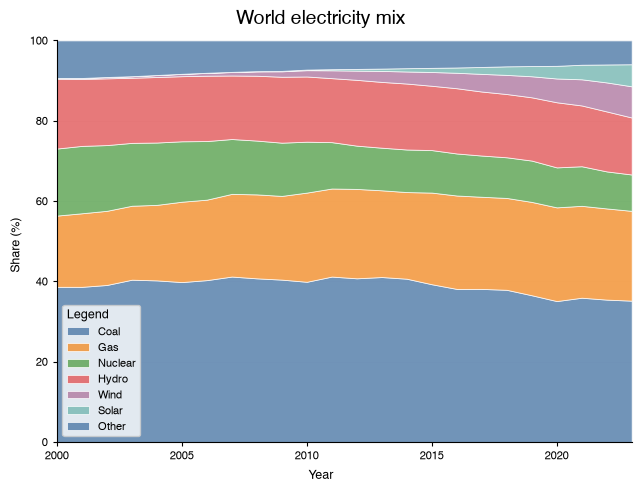

In [10]:
StackedAreaChart(
    data=generation,
    # every year sums to 100: the bands are shares
    baseline=STACKED_AREA_BASELINE.PERCENT,
    subtitle=SOURCES,
    show_legend=True,
    title="World electricity mix",
    xlabel="Year",
    ylabel="Share (%)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

The remaining baselines centre the stack instead of resting it on zero. `SYM` centres it on the x-axis; `WIGGLE` and `WEIGHTED_WIGGLE` pick, at every x, the baseline that keeps the bands flattest — the streamgraph look, which reads best when the series are many and the total matters little. Only the ZERO and PERCENT baselines pin the y-axis at zero; the others keep the usual margin around the stack.

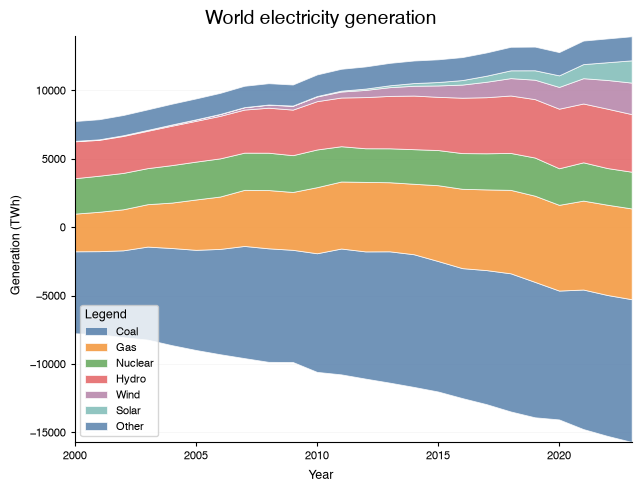

In [11]:
StackedAreaChart(
    data=generation,
    # a streamgraph: the baseline wiggles to flatten the bands
    baseline=STACKED_AREA_BASELINE.WEIGHTED_WIGGLE,
    subtitle=SOURCES,
    show_legend=True,
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Band style

To change the band style, add the `style` attribute with the corresponding attributes. The supported attributes are shown in the [datachart.typings.StackedAreaStyleAttrs](../../../references/typings/#datachart.typings.StackedAreaStyleAttrs) typing: the fill takes the `plot_area_*` color, hatch and zorder, its alpha comes from `plot_stackedarea_alpha`, the bands are separated by a stroke in `plot_stackedarea_edge_color` at `plot_stackedarea_edge_width`, and `plot_stackedarea_outline` draws the top edge of every band as a line in the `plot_line_*` style. A single dictionary applies to every series; a list, aligned with `data`, styles each on its own. The example groups the fossil sources in warm colors and the low-carbon ones in cool colors, with outlines to separate the bands.

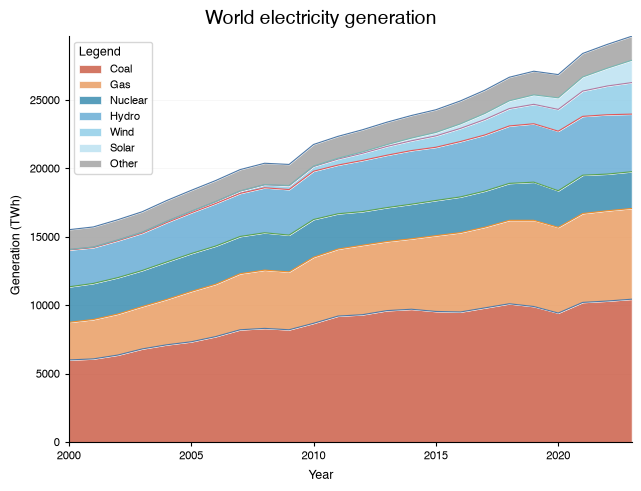

In [12]:
FOSSIL, CLEAN = "#C8553D", "#2E86AB"
StackedAreaChart(
    data=generation,
    # one style per series: fossil sources warm, the rest cool
    style=[
        {"plot_area_color": color, "plot_stackedarea_outline": True, "plot_line_width": 0.8}
        for color in (FOSSIL, "#E8975A", CLEAN, "#5FA8D3", "#8ACBE6", "#B8E0F0", "#9E9E9E")
    ],
    subtitle=SOURCES,
    show_legend=True,
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Value labels

To print each series' value at the midpoint of its band, add the `show_values` attribute. `value_format` controls the formatting ([datachart.constants.VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT)) and `value_step` labels every Nth x position when the bands are too dense to label every point (by default the step keeps neighbouring labels apart). With the percent baseline the labels print the shares. The example labels the mix every fourth year.

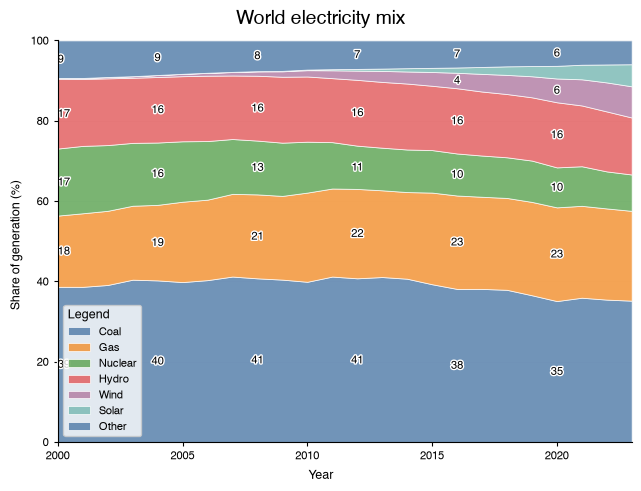

In [13]:
from datachart.constants import VALUE_FORMAT

StackedAreaChart(
    data=generation,
    baseline=STACKED_AREA_BASELINE.PERCENT,
    subtitle=SOURCES,
    show_legend=True,
    # print the share of every source every fourth year
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
    value_step=4,
    title="World electricity mix",
    xlabel="Year",
    ylabel="Share of generation (%)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Emphasis

When a stack carries several series, the story is often about one of them. The `emphasis` attribute expresses that directly: `"highlight"` brings a band to the front, `"background"` mutes it (the theme's muted color at a lower alpha, dropped from the legend), and `None` leaves it unchanged. `emphasis` is a list aligned with `data`, just like `subtitle` and `style`; the role strings are also available as the [datachart.constants.EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constants. The stack itself does not change — a muted band keeps its place, so the bands above it stay where they were.

The example highlights wind and solar against the rest of the mix. See the [Highlighting](../../styling/highlighting/) guide for how emphasis works across all chart types and themes.

To pick the series from the data instead, pass `emphasis_rule`, a one-key rule — `{"above": v}` or `{"below": v}` (strict), `{"between": (lo, hi)}` (inclusive), `{"top": n}` or `{"bottom": n}` — that highlights every series whose summary matches and mutes the rest. The summary is the mean of each series's own `y` values (never the stacked position) by default; a `"by"` key picks `"median"`, `"min"`, `"max"`, or `"sum"` instead, as in `{"top": 1, "by": "max"}`. An explicit `emphasis` role wins over the rule. See the [Highlighting](../../styling/highlighting/#emphasis-picked-by-a-rule) guide for the rule on every chart.

In [14]:
from datachart.constants import EMPHASIS

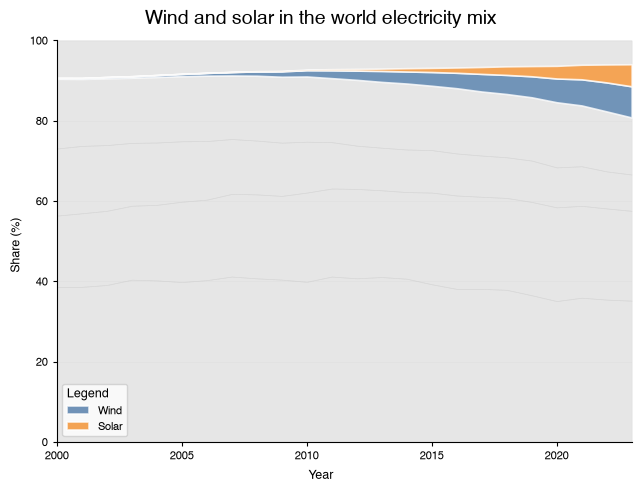

In [15]:
StackedAreaChart(
    data=generation,
    baseline=STACKED_AREA_BASELINE.PERCENT,
    # mute everything but wind and solar
    emphasis=[
        EMPHASIS.HIGHLIGHT if source in ("Wind", "Solar") else EMPHASIS.BACKGROUND
        for source in SOURCES
    ],
    subtitle=SOURCES,
    show_legend=True,
    title="Wind and solar in the world electricity mix",
    xlabel="Year",
    ylabel="Share (%)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Reference lines

A reference line marks a position on the chart. To add vertical lines, add the `vlines` attribute with the [datachart.typings.VLineSettingAttrs](../../../references/typings/#datachart.typings.VLineSettingAttrs) typing; for horizontal lines, add the `hlines` attribute with the [datachart.typings.HLineSettingAttrs](../../../references/typings/#datachart.typings.HLineSettingAttrs) typing. The lines below mark the 2015 Paris Agreement and the 2020 pandemic dip, and the level of total generation in 2000. Both attributes take a `style` dictionary; the [datachart.constants.LINE_STYLE](../../../references/constants/#datachart.constants.LINE_STYLE) constant holds the line styles. A single line or list of lines applies to every series, so a stack of seven would draw each line seven times; a list aligned with `data` attaches the lines to one series — here the first — and draws them once.

In [16]:
from datachart.constants import LINE_STYLE

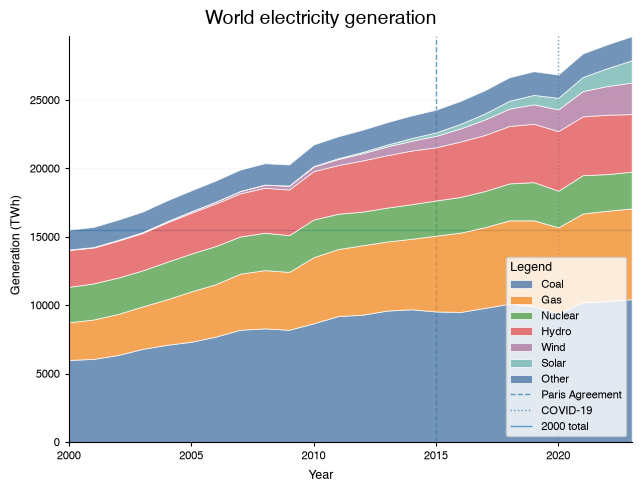

In [17]:
StackedAreaChart(
    data=generation,
    subtitle=SOURCES,
    show_legend=True,
    # mark two years and the 2000 total, attached to the first series only
    vlines=[
        [
            {"x": 2015, "label": "Paris Agreement", "style": {"plot_vline_style": LINE_STYLE.DASHED}},
            {"x": 2020, "label": "COVID-19", "style": {"plot_vline_style": LINE_STYLE.DOTTED}},
        ]
    ]
    + [None] * (len(SOURCES) - 1),
    hlines=[{"y": sum(values[0] for values in GENERATION.values()), "label": "2000 total"}]
    + [None] * (len(SOURCES) - 1),
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Reference bands

A reference band shades a region — an acceptable range, a period, a tolerance around a value — over the grid lines and under the marks. To add horizontal bands, add the `hspans` attribute with the [datachart.typings.HSpanSettingAttrs](../../../references/typings/#datachart.typings.HSpanSettingAttrs) typing, which is either a `dict` or a `List[dict]` where each dictionary sets `ymin` and/or `ymax`, an optional `label` for the legend, and an optional `style` with the `plot_hspan_*` attributes (color, alpha, hatch, edge color and width, zorder). Vertical bands work the same way through the `vspans` attribute and the [datachart.typings.VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs) typing, with `xmin`, `xmax` and `plot_vspan_*` attributes. At least one bound is required; an omitted bound runs to the axis edge. The [Line Chart](../linechart/#reference-bands) guide lists every attribute of a band.

A single band applies to the whole stack and draws once; a list aligned with `data` attaches bands to individual series instead. The example shades the 2008–2009 financial crisis, the one period before 2020 in which generation dipped.


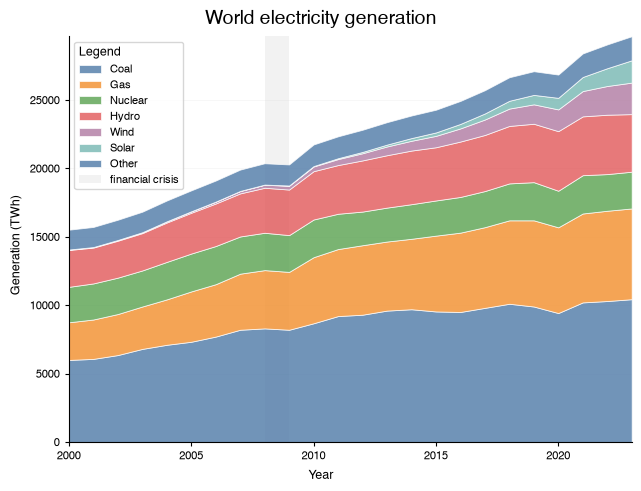

In [18]:
StackedAreaChart(
    data=generation,
    subtitle=SOURCES,
    show_legend=True,
    # shade the financial crisis; one band applies to the whole stack
    vspans={"xmin": 2008, "xmax": 2009, "label": "financial crisis"},
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Text annotations

To place text on the chart, add the `texts` attribute with the [datachart.typings.TextSettingAttrs](../../../references/typings/#datachart.typings.TextSettingAttrs) typing. Each annotation sets its `text` and position, in data coordinates by default or in axes fractions with `"coords": "axes"`, and an optional `target` point to draw a connector to. The annotation below points at the year solar generation passed 1,000 TWh.

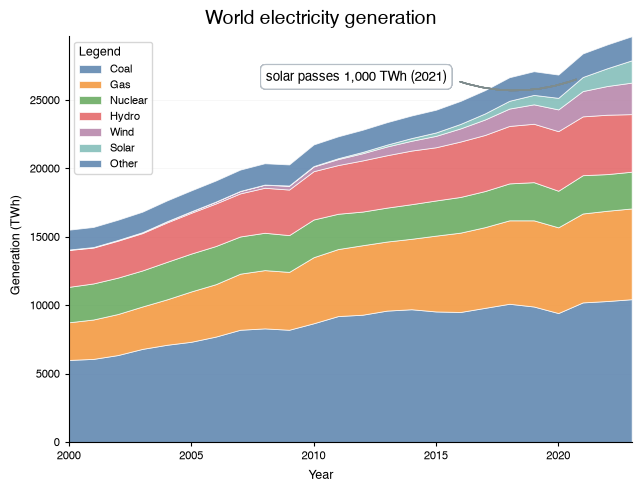

In [19]:
SOLAR_1000 = next(year for year, twh in zip(YEARS, GENERATION["Solar"]) if twh >= 1000)
# the top of the solar band that year: everything stacked below it plus solar itself
solar_top = sum(GENERATION[source][YEARS.index(SOLAR_1000)] for source in SOURCES[: SOURCES.index("Solar") + 1])

StackedAreaChart(
    data=generation,
    subtitle=SOURCES,
    show_legend=True,
    # point at the year solar passed 1,000 TWh
    texts={
        "text": f"solar passes 1,000 TWh ({SOLAR_1000})",
        "x": 0.35,
        "y": 0.9,
        "coords": "axes",
        "target": (SOLAR_1000, solar_top),
    },
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Multiple Stacked Area Charts

### Subplots

A stacked area chart is already a multi-series chart; the `subplots` attribute takes the stack apart instead, drawing each series unstacked in its own subplot, from zero, so the sources can be compared at their own scale. The `subtitle` becomes the subplot title and the `title`, `xlabel` and `ylabel` are positioned to be global for all charts. The `max_cols` attribute limits the number of columns, and `sharex` and `sharey` share an axis across the subplots; a shared axis is labeled once, on the outer subplots only.

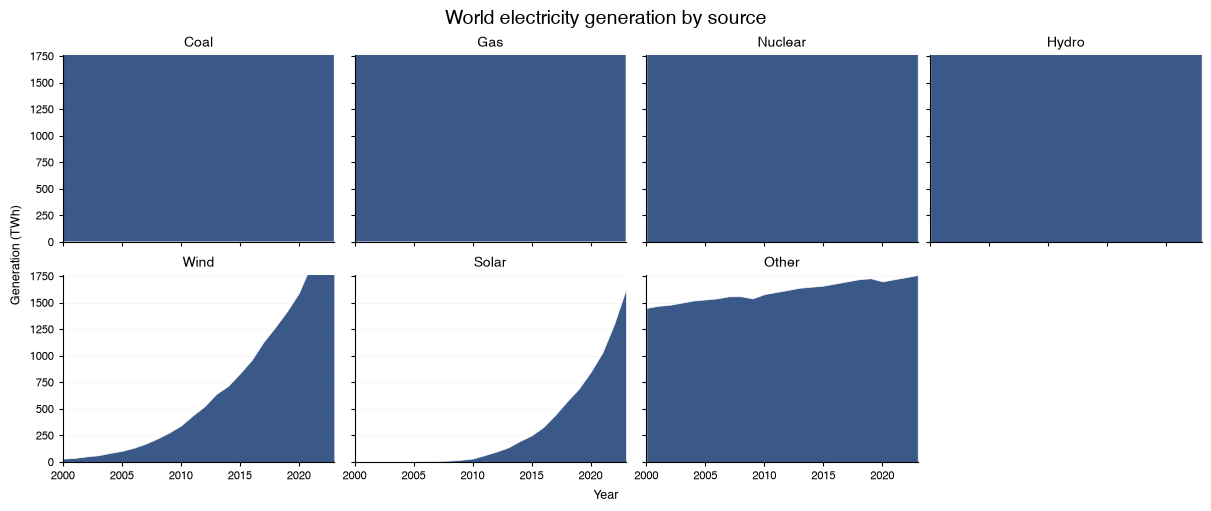

In [20]:
StackedAreaChart(
    data=generation,
    subtitle=SOURCES,
    # one series per subplot, unstacked
    subplots=True,
    max_cols=4,
    sharex=True,
    sharey=True,
    title="World electricity generation by source",
    xlabel="Year",
    ylabel="Generation (TWh)",
    figsize=(12, 5),
).show()

### Composing stacked areas

A stacked area figure composes like any other chart. [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) overlays it with other charts on shared axes — the natural pairing is a [datachart.charts.LineChart](../../../references/charts/#datachart.charts.LineChart) of a related total or target drawn over the stack. Other charts in the panel sit on top of the stack without joining it; the panel keeps the stack's baseline. The line below is the low-carbon total — nuclear, hydro, wind and solar together — over the full mix.

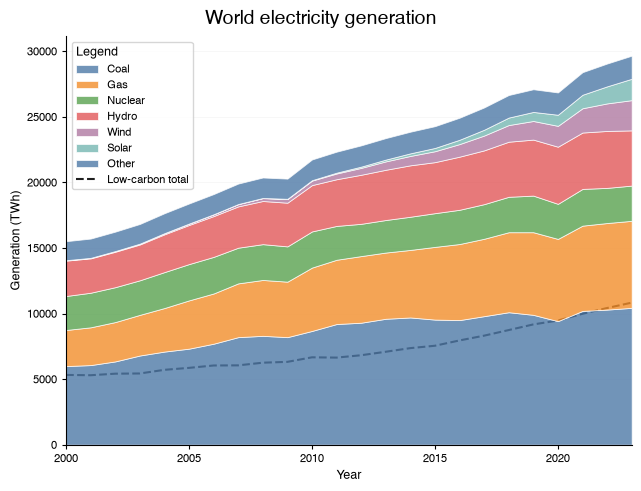

In [21]:
from datachart.charts import LineChart
from datachart.utils import Panel

LOW_CARBON = ["Nuclear", "Hydro", "Wind", "Solar"]
low_carbon = [
    {"x": year, "y": sum(GENERATION[source][i] for source in LOW_CARBON)}
    for i, year in enumerate(YEARS)
]

stack = StackedAreaChart(data=generation, subtitle=SOURCES)
total = LineChart(
    data=low_carbon,
    subtitle="Low-carbon total",
    style={"plot_line_color": "#1F1F1F", "plot_line_style": LINE_STYLE.DASHED},
)
Panel(
    [stack, total],
    title="World electricity generation",
    xlabel="Year",
    ylabel_left="Generation (TWh)",
    show_legend=True,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

[datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) arranges stacked area figures next to other figures. The generation spans the top row; the mix in percent and a bar chart of the 2023 generation share the bottom one.

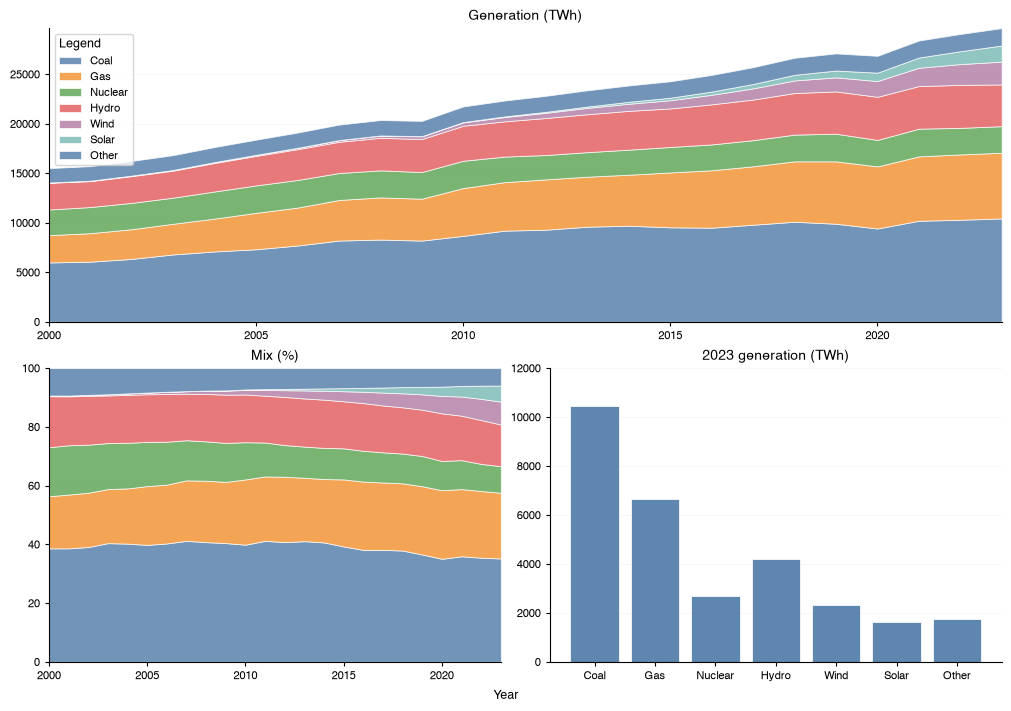

In [22]:
from datachart.charts import BarChart
from datachart.utils import Grid

top = StackedAreaChart(data=generation, subtitle=SOURCES, title="Generation (TWh)", show_legend=True)
left = StackedAreaChart(
    data=generation, baseline=STACKED_AREA_BASELINE.PERCENT, subtitle=SOURCES, title="Mix (%)"
)
right = BarChart(
    data=[{"label": source, "y": GENERATION[source][-1]} for source in SOURCES],
    title="2023 generation (TWh)",
    show_values=False,
)
Grid([[top], [left, right]], xlabel="Year", figsize=(10, 7)).show()

## Additional Features

### Custom data keys

By default the chart reads the `x` and `y` keys of every point. When the data uses other names, add the `x` and `y` attributes with the key names — the hidden cell below holds the same generation as `year`/`twh` records.

In [23]:
records = [
    [{"year": year, "twh": twh} for year, twh in zip(YEARS, GENERATION[source])]
    for source in SOURCES
]

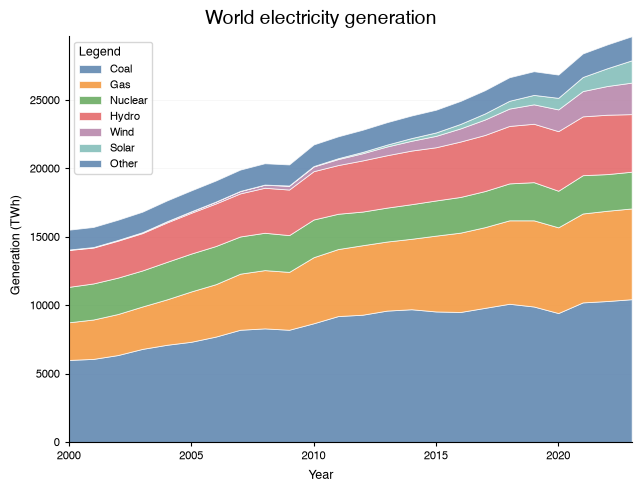

In [24]:
StackedAreaChart(
    data=records,
    # read the year and twh keys instead of x and y
    x="year",
    y="twh",
    subtitle=SOURCES,
    show_legend=True,
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Datetime axis

The series' `x` values may be real temporal objects — `datetime`, `date`, `numpy.datetime64`, or pandas `Timestamp` — instead of numbers; the same generation data keyed by the first day of each year draws on a time axis. Points sit at their elapsed time and the ticks pick concise, non-repeating labels for the visible span; date strings are not parsed and draw as categories. `xticks_format` takes a [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) member or any `strftime` pattern, and explicit `xticks`, `xmin` / `xmax`, reference lines, and reference bands take datetimes as well.


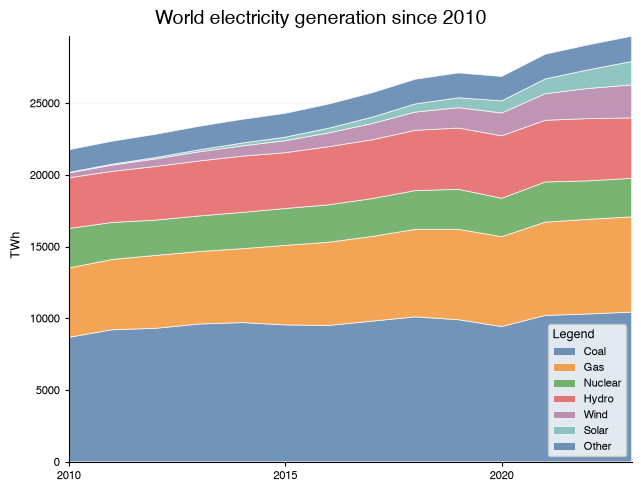

In [25]:
from datetime import date

from datachart.constants import DATE_FORMAT

generation_dated = [
    [{"x": date(year, 1, 1), "y": twh} for year, twh in zip(YEARS, GENERATION[source])]
    for source in SOURCES
]

StackedAreaChart(
    data=generation_dated,
    subtitle=SOURCES,
    title="World electricity generation since 2010",
    ylabel="TWh",
    # the axis reads as time: a datetime limit and one tick per five years
    xmin=date(2010, 1, 1),
    xticks=[date(year, 1, 1) for year in range(2010, 2024, 5)],
    xticks_format=DATE_FORMAT.YEAR,
    show_legend=True,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Themes

A theme sets the palette, the band alpha and the furniture of every chart at once; see the [Theme Gallery](../../styling/theme-gallery/) for the whole suite under each. Apply one with [datachart.config.Config.set_theme](../../../references/config/#datachart.config.Config.set_theme) from the [datachart.constants.THEME](../../../references/constants/#datachart.constants.THEME) constant, and reset the configuration afterwards so the following charts draw in the default again.

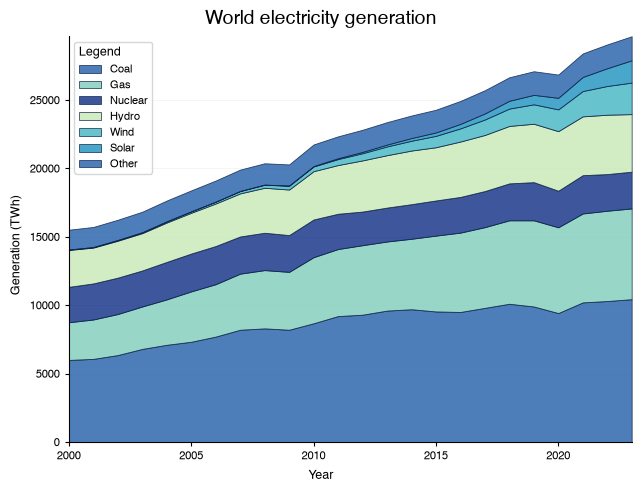

In [26]:
from datachart.config import config
from datachart.constants import THEME

config.set_theme(THEME.INK)
figure = StackedAreaChart(
    data=generation,
    subtitle=SOURCES,
    show_legend=True,
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
    figsize=FIG_SIZE.FULL_MEDIUM,
)
config.reset_config()
figure.show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [27]:
from datachart.utils import save_figure

figure = StackedAreaChart(
    data=generation,
    subtitle=SOURCES,
    show_legend=True,
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
)
save_figure(figure, "./fig_stacked_area_chart.png", dpi=300)

['./fig_stacked_area_chart.png']

The figure should be saved in the current working directory.

## Real-World Examples

The following examples put the features above to work on the generation data. Each one states what it shows; any derived data lives in a hidden cell.

### Example 1: Fossil Versus Low-Carbon Generation (Grouped Series, Percent Baseline, and Emphasis)

The seven sources collapse into three groups in the hidden cell — fossil (coal, gas), low-carbon (nuclear, hydro, wind, solar), and other — and the percent baseline turns them into shares. With the fossil band highlighted and the rest muted, the chart makes one point: the fossil share of the world's electricity has barely moved in two decades, because generation grew as fast as the low-carbon sources did. A reference line at 50 % and an annotation on the 2023 fossil share anchor the reading.

In [28]:
GROUPS = {
    "Fossil": ["Coal", "Gas"],
    "Low-carbon": ["Nuclear", "Hydro", "Wind", "Solar"],
    "Other": ["Other"],
}
grouped = [
    [
        {"x": year, "y": sum(GENERATION[source][i] for source in members)}
        for i, year in enumerate(YEARS)
    ]
    for members in GROUPS.values()
]
totals = [sum(GENERATION[source][i] for source in SOURCES) for i in range(len(YEARS))]
FOSSIL_2023 = 100 * grouped[0][-1]["y"] / totals[-1]

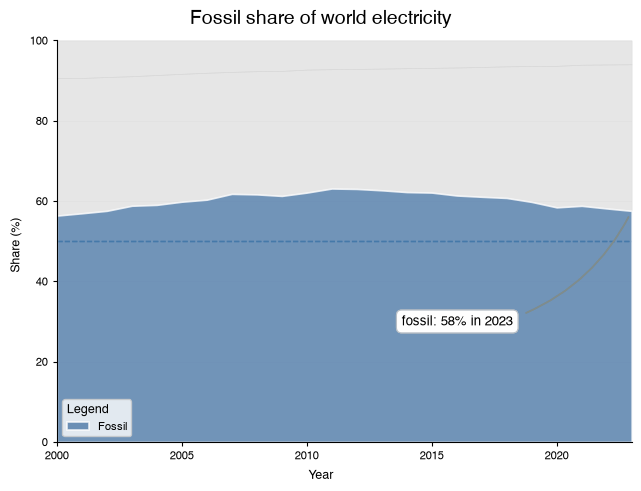

In [29]:
StackedAreaChart(
    data=grouped,
    baseline=STACKED_AREA_BASELINE.PERCENT,
    subtitle=list(GROUPS),
    emphasis=[EMPHASIS.HIGHLIGHT, EMPHASIS.BACKGROUND, EMPHASIS.BACKGROUND],
    show_legend=True,
    hlines={"y": 50, "style": {"plot_hline_style": LINE_STYLE.DASHED}},
    texts={
        "text": f"fossil: {FOSSIL_2023:.0f}% in 2023",
        "x": 0.6,
        "y": 0.3,
        "coords": "axes",
        "target": (2023, FOSSIL_2023),
    },
    title="Fossil share of world electricity",
    xlabel="Year",
    ylabel="Share (%)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 2: The Rise of Wind and Solar (Streamgraph, Outlines, and a Grid)

Wind and solar are the two sources that grew from nothing, and a streamgraph — the weighted-wiggle baseline — shows growth by band thickness without a total to distract from it. The grid pairs the streamgraph of the two sources with their share of the world's electricity on the percent baseline, the bands outlined so the thin early years stay visible.

In [30]:
renewables = [generation[SOURCES.index(source)] for source in ("Wind", "Solar")]
renewable_shares = [
    [{"x": year, "y": 100 * GENERATION[source][i] / totals[i]} for i, year in enumerate(YEARS)]
    for source in ("Wind", "Solar")
]

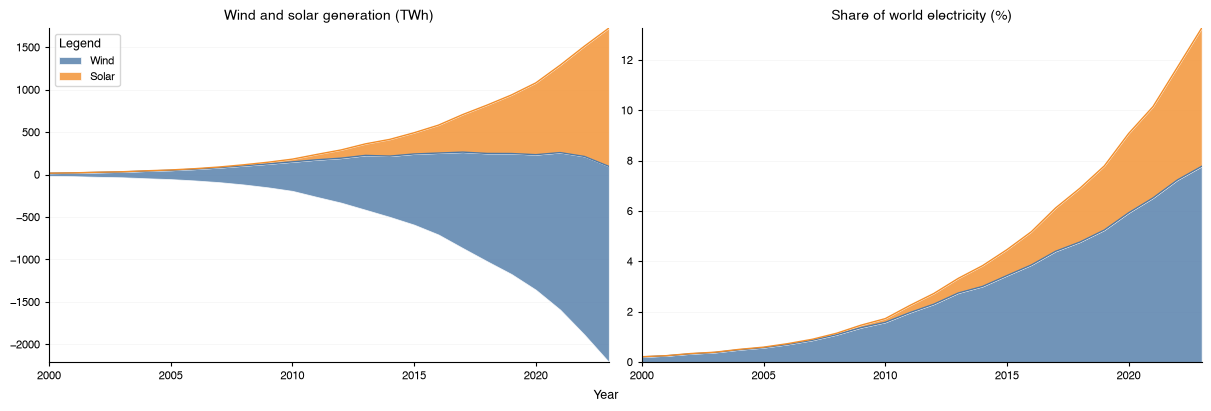

In [31]:
outlined = {"plot_stackedarea_outline": True, "plot_line_width": 1.0}
stream = StackedAreaChart(
    data=renewables,
    baseline=STACKED_AREA_BASELINE.WEIGHTED_WIGGLE,
    subtitle=["Wind", "Solar"],
    style=outlined,
    title="Wind and solar generation (TWh)",
    show_legend=True,
)
share = StackedAreaChart(
    data=renewable_shares,
    subtitle=["Wind", "Solar"],
    style=outlined,
    title="Share of world electricity (%)",
)
Grid([[stream, share]], xlabel="Year", figsize=(12, 4)).show()